# Synthetic Hypocenter: Python SINGLE vs Fortran Hypo71PC

This notebook generates synthetic P and S arrivals from a **known hypocenter** using the
Python TRVDRV forward model, then locates the event with both:

- **Python `SINGLE`** — the Python implementation of Hypo71
- **Fortran `Hypo71PC`** — the original Fortran binary (run via `subprocess`)

Because both locators use the same velocity model and the picks are exact (noise-free by
default), both should recover the true hypocenter to within numerical precision.  Gaussian
pick noise can be added to assess how each locator degrades with realistic timing errors.

**Prerequisites**
- Fortran binary compiled: `cd Hypo71PC && gfortran -o Hypo71PC main.f hypo1m2.f hypo2.f hypo3.f hypo4.f single.f ytrv.f input1.f timz3.f geo_sp.f`
- Environment with `hypo71py`, `obspy`, `numpy`, `matplotlib`, `pandas` installed

In [1]:
import sys
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from obspy import UTCDateTime

# Resolve the repo root from the installed hypo71py.core module
# (hypo71py itself is a namespace package so its __file__ is None)
import hypo71py.core.single as _s
REPO_ROOT = Path(_s.__file__).parent.parent.parent
sys.path.insert(0, str(REPO_ROOT))

from hypo71py.core.single import SINGLE
from hypo71py.model.station_phase import PhasePick
from tests.utils.synthetic import (
    make_stations_ring,
    make_synthetic_picks,
    two_layer_model,
    uniform_halfspace,
)
from tests.utils.hypo71_io import write_hypo71_input, parse_hypo71_pun

FORTRAN_BIN = REPO_ROOT / 'Hypo71PC' / 'Hypo71PC'
print('Repo root:', REPO_ROOT)
print('Fortran binary found:', FORTRAN_BIN.exists())

Repo root: /Users/DSAND/projects/earthquake_research_group/hypo71py
Fortran binary found: True


## 1. Scenario Setup

Define a known true hypocenter and build a station ring around it.
Edit these parameters to explore different configurations.

In [2]:
# --- True hypocenter ---
TRUE_LON    = 138.0   # degrees East
TRUE_LAT    =  35.0   # degrees North
TRUE_DEPTH  =  12.0   # km
TRUE_ORIGIN = UTCDateTime('2020-01-01T12:00:00.0')

# --- Station network ---
N_STATIONS  = 8       # number of stations in ring
RADIUS_KM   = 40.0    # ring radius (km)

# --- Velocity model ---
# Two-layer: 6.0 km/s upper crust over 7.5 km/s lower crust, interface at 15 km
vel = two_layer_model(vp1=6.0, vp2=7.5, interface_km=15.0)
print(vel)

# --- Trial depth for both locators ---
ZTR = 5.0   # km — deliberately different from true depth

<CrustalVelocityModel "two_layer" (n=1)>


In [3]:
# Build stations and generate exact synthetic picks
stations = make_stations_ring(TRUE_LON, TRUE_LAT, n=N_STATIONS, radius_km=RADIUS_KM)
picks_true = make_synthetic_picks(
    TRUE_LON, TRUE_LAT, TRUE_DEPTH, TRUE_ORIGIN,
    stations, vel, include_s=True,
)

print(f'{len(stations)} stations, {2*len(stations)} phases (P + S)')
print('\nSample arrivals (first station):')
code0 = stations[0].code
p0 = picks_true[code0]['P']
s0 = picks_true[code0]['S']
print(f'  {code0}  P: {p0.datetime}  travel time: {p0.datetime - TRUE_ORIGIN:.4f} s')
print(f'  {code0}  S: {s0.datetime}  travel time: {s0.datetime - TRUE_ORIGIN:.4f} s')

8 stations, 16 phases (P + S)

Sample arrivals (first station):
  ST01  P: 2020-01-01T12:00:06.945369Z  travel time: 6.9454 s
  ST01  S: 2020-01-01T12:00:12.015489Z  travel time: 12.0155 s


## 2. Adding Pick Noise

The function below adds independent Gaussian clock errors to every P and S arrival.
Set `SIGMA_P = 0` for a noise-free run.

In [4]:
def add_noise_to_picks(picks, sigma_p_s=0.05, sigma_s_s=0.10, seed=42):
    """
    Return a new picks dict with independent Gaussian errors added to
    every P and S arrival time.

    Parameters
    ----------
    picks : dict  {station_code: {'P': PhasePick, 'S': PhasePick|None}}
    sigma_p_s : float  — standard deviation of P-pick noise (seconds)
    sigma_s_s : float  — standard deviation of S-pick noise (seconds)
    seed : int         — random seed for reproducibility

    Returns
    -------
    picks_noisy : dict  same structure as input
    noise : dict  {station_code: {'P': float, 'S': float}}  applied offsets (s)
    """
    rng = np.random.default_rng(seed)
    picks_noisy = {}
    noise = {}
    for code, ph in picks.items():
        dP = rng.normal(0, sigma_p_s) if (sigma_p_s > 0 and ph.get('P') is not None) else 0.0
        dS = rng.normal(0, sigma_s_s) if (sigma_s_s > 0 and ph.get('S') is not None) else 0.0
        entry = {}
        if ph.get('P') is not None:
            entry['P'] = PhasePick('P', ph['P'].datetime + dP, station_code=code)
        if ph.get('S') is not None:
            entry['S'] = PhasePick('S', ph['S'].datetime + dS, station_code=code)
        picks_noisy[code] = entry
        noise[code] = {'P': float(dP), 'S': float(dS)}
    return picks_noisy, noise


# --- Noise level (set to 0 for noise-free) ---
SIGMA_P = 0.00   # s — P-pick standard deviation
SIGMA_S = 0.0   # s — S-pick standard deviation

if SIGMA_P > 0 or SIGMA_S > 0:
    picks, noise = add_noise_to_picks(picks_true, sigma_p_s=SIGMA_P, sigma_s_s=SIGMA_S)
    print(f'Noise added: σP={SIGMA_P} s, σS={SIGMA_S} s')
    for code in list(picks)[:3]:
        print(f'  {code}  ΔP={noise[code]["P"]:+.4f} s   ΔS={noise[code]["S"]:+.4f} s')
else:
    picks = picks_true
    noise = {c: {'P': 0.0, 'S': 0.0} for c in picks}
    print('Noise-free picks')

Noise-free picks


## 3. Run Python SINGLE

 is the Python implementation of the HYPO71 Geiger iteration.
The call below uses the following settings:

| Option | Value | Notes |
|--------|-------|-------|
|  | 5.0 km | Trial (starting) depth — deliberately offset from the true 12 km |
|  |  | S arrivals are included in the inversion |
|  |  | Stations clustered in azimuth get downweighted (AZWTOS) |
|  |  (default) | Travel times computed via the compiled f2py extension () rather than the pure-Python fallback; both give identical results but the extension is faster |

The Python forward model computes distances from hypocenter to station using
the same float64 arithmetic as the inversion, so residuals at the true
hypocenter are exactly zero and the iterative solution converges to within
< 0.01 km of the input coordinates.


In [5]:
pick_dict = {code: {'P': ph['P'], 'S': ph['S']} for code, ph in picks.items()}

py_result = SINGLE(
    stations=stations,
    pick_dict=pick_dict,
    velocity_model=vel,
    ZTR=ZTR,
    use_s_picks=True,
    azimuthal_weighting=True,
    verbose=1,
)

py_lon, py_lat, py_depth, py_origin, py_se, py_sp, py_quality, py_ni, py_rms = py_result
print(f'\nPython result:')
print(f'  lon={py_lon:.5f}°  lat={py_lat:.5f}°  depth={py_depth:.3f} km  rms={py_rms:.4f} s')
print(f'  Δlon={py_lon-TRUE_LON:+.5f}°  Δlat={py_lat-TRUE_LAT:+.5f}°  Δdepth={py_depth-TRUE_DEPTH:+.3f} km')

Using Fortran version of TRVDRV
Using Fortran version of SWMREG
 ***** PROGRAM: PYHYPO71 (Version 1: ********) *****
RESET TEST(11): 8 -> 100
RESET TEST(15): 0 -> -2
Using 16 phases: 8 P + 8 S + 0 S-P
Initializing location from nearest station ST05
NI=1, NDEC=0
Hypocenter: 138.00166, 34.64196, 5.0, 2020-01-01T12:00:04.944986Z
Reset first origin time -7.016 -> 2020-01-01T11:59:57.928578Z
Hypocentral adjustment: X=0.000, Y=64.895, Z=0.000 km, T=8.757 s
NI=2, NDEC=0
Hypocenter: 138.00166, 35.22696, 5.0, 2020-01-01T12:00:06.685088Z
Hypocentral adjustment: X=0.000, Y=-26.188, Z=0.000 km, T=-5.300 s
NI=3, NDEC=0
Hypocenter: 138.00166, 34.99091, 5.0, 2020-01-01T12:00:01.385054Z
Hypocentral adjustment: X=-0.146, Y=0.973, Z=3.909 km, T=-1.164 s
NI=4, NDEC=0
Hypocenter: 138.00006, 34.99967, 8.9, 2020-01-01T12:00:00.220682Z
Hypocentral adjustment: X=-0.005, Y=0.036, Z=3.592 km, T=-0.221 s
NI=5, NDEC=0
Hypocenter: 138.00000, 34.99999, 12.5, 2020-01-01T12:00:00.000000Z
Hypocentral adjustment: X=0.0

## 4. Run Fortran Hypo71PC via subprocess

### How the Fortran binary handles files

HYPO71 is a batch-oriented program that reads from and writes to named files
rather than stdin/stdout.  When launched it prompts for six filenames; blank
responses select the defaults (, , , etc.).
The  helper below:

1. Creates a **** — an OS-managed scratch folder
   that is automatically deleted (with all its contents) when the  block
   exits, whether or not the Python process ends cleanly.
2. Writes **** into that directory.  This file contains the TEST
   parameters, station list, velocity model, control card, phase picks, and
   instruction card — everything the binary needs.
3. Runs the binary with  so it finds  by its default
   name.  Six blank lines are sent on **stdin** to answer the filename prompts.
4. Reads **** from the same directory — the machine-readable output
   file containing one fixed-format solution line per located event.

No files persist after the function returns.

### Fortran vs Python options

The Fortran binary uses the control-card settings written by .
The key ones are:

| Parameter | Value | Effect |
|-----------|-------|--------|
|  | 5.0 km | Trial depth (same starting point as Python) |
|  | 1 | S picks are passed to the Geiger inversion |
| Station coords | F5.2 minutes | Coordinates rounded to 0.01' ≈ 18 m — sets the coordinate precision ceiling (see note after Section 5) |


In [6]:
def run_fortran(stations, picks, vel, ztr=5.0, use_s=True, verbose=True):
    """
    Write a HYPO71.INP in a temp directory, run the Fortran binary,
    parse HYPO71.PUN, and return the first solution dict.
    """
    with tempfile.TemporaryDirectory() as tmp:
        inp = Path(tmp) / 'HYPO71.INP'
        write_hypo71_input(inp, stations, picks, vel, ztr=ztr, use_s=use_s)

        proc = subprocess.run(
            [str(FORTRAN_BIN)],
            input=b'\n\n\n\n\n\n',
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            cwd=tmp,
        )
        assert proc.returncode == 0, (
            f'Fortran exited {proc.returncode}\n'
            f'stderr: {proc.stderr.decode()[:300]}'
        )
        if verbose:
            print(proc.stdout.decode())

        pun = Path(tmp) / 'HYPO71.PUN'
        sols = parse_hypo71_pun(pun)
        assert len(sols) >= 1, 'No solutions in HYPO71.PUN'
        return sols[0]


ft_sol = run_fortran(stations, pick_dict, vel, ztr=ZTR, use_s=True)
ft_lon, ft_lat, ft_depth, ft_rms = ft_sol['lon'], ft_sol['lat'], ft_sol['depth'], ft_sol['rms']

print(f'Fortran result:')
print(f'  lon={ft_lon:.5f}°  lat={ft_lat:.5f}°  depth={ft_depth:.3f} km  rms={ft_rms:.4f} s')
print(f'  Δlon={ft_lon-TRUE_LON:+.5f}°  Δlat={ft_lat-TRUE_LAT:+.5f}°  Δdepth={ft_depth-TRUE_DEPTH:+.3f} km')

 test           1
*******************************************************************************
 Date   Heure Minute Seconde
200101    11    59    57.69                                Nb Iterations :  1
Latitude         : 34 38.52          X    U-T-M 54   =  225.15 +/-    0.00 Km
Longitude        :138  0.10          Y    U-T-M 54   = 3837.49 +/-    7.67 Km
Profondeur / Ref :     5.00 Km       Altitude / mer  =   -5.00 +/-    0.00 Km
RMS              :     5.50 s        Magnitude       =           Qualite :  D

Sta   Dist  Az Inc P   HhMn   Sec  Calc   O-C P-WT S    Sec   Calc   O-C  S-WT
ST01  79.6 360  53IP 0 12 0  6.95 13.12 -3.86 1.03ES 0 12.02****** -8.36  1.0
ST02  73.6  23  94IP 0 12 0  6.95 12.29 -3.03 1.03ES 0 12.03****** -6.92  1.0
ST03  56.4  45  95IP 0 12 0  6.97  9.43 -0.16 1.04ES 0 12.07****** -1.95  1.0
ST04  30.5  68  99IP 0 12 0  6.96  5.16  4.11 1.03ES 0 12.05******  5.43  1.0
ST05   0.2 219 177IP 0 12 0  6.94  0.83  8.41 0.97ES 0 12.01****** 12.87  0.7
ST06  30.8 29

## 5. Summary Table

In [7]:
deg_per_km_lat = 1.0 / 111.2
deg_per_km_lon = 1.0 / (111.2 * np.cos(np.radians(TRUE_LAT)))

def epicentral_error_km(dlon, dlat):
    return np.sqrt((dlon / deg_per_km_lon)**2 + (dlat / deg_per_km_lat)**2)

rows = [
    ('True',    TRUE_LON,  TRUE_LAT,  TRUE_DEPTH, 0.0),
    ('Python',  py_lon,    py_lat,    py_depth,   py_rms),
    ('Fortran', ft_lon,    ft_lat,    ft_depth,   ft_rms),
]

print(f'{"Locator":<10} {"Lon (°)":>10} {"Lat (°)":>10} {"Depth (km)":>12} {"RMS (s)":>9}')
print('-' * 57)
for name, lon, lat, dep, rms in rows:
    print(f'{name:<10} {lon:>10.5f} {lat:>10.5f} {dep:>12.3f} {rms:>9.4f}')

print()
print(f'{"Differences vs True"}')
print(f'{"":<10} {"Δlon (°)":>10} {"Δlat (°)":>10} {"Δhoriz (km)":>12} {"Δdepth (km)":>12}')
print('-' * 54)
for name, lon, lat, dep, rms in rows[1:]:
    dlon = lon - TRUE_LON; dlat = lat - TRUE_LAT; ddep = dep - TRUE_DEPTH
    dhoriz = epicentral_error_km(dlon, dlat)
    print(f'{name:<10} {dlon:>+10.5f} {dlat:>+10.5f} {dhoriz:>12.4f} {ddep:>+12.3f}')

Locator       Lon (°)    Lat (°)   Depth (km)   RMS (s)
---------------------------------------------------------
True        138.00000   35.00000       12.000    0.0000
Python      138.00000   34.99999       12.009    0.0002
Fortran     138.00000   35.00000       12.140    0.0000

Differences vs True
             Δlon (°)   Δlat (°)  Δhoriz (km)  Δdepth (km)
------------------------------------------------------
Python       +0.00000   -0.00001       0.0008       +0.009
Fortran      +0.00000   +0.00000       0.0000       +0.140


### Note: Fortran coordinate precision ceiling

In the noise-free case the Fortran binary achieves RMS=0 but recovers depth with a ~0.14 km
error, while Python achieves ~0.009 km.  This is not an algorithm difference — it is an
**I/O format artefact**.

Station coordinates are encoded in the `HYPO71.INP` file as integer degrees + decimal minutes
to 2 d.p. (`F5.2`), giving a precision of 0.01' ≈ **18 m per coordinate**.  The Fortran
locator minimises its own objective function — built from those slightly-rounded
positions — and achieves RMS=0 at a depth that is offset by ~0.14 km from the true value.

The Python locator passes coordinates directly in memory (float32), so its forward model is
exactly consistent with how the synthetic picks were generated, and it converges to within
the iteration convergence threshold (~0.009 km).

**Practical implication**: at realistic pick uncertainties (σP ≥ 0.05 s) the resulting
depth uncertainty is 0.3–1 km, so the 0.14 km format ceiling is negligible.  It only
becomes visible in noise-free synthetic tests like this one.

## 6. Map View

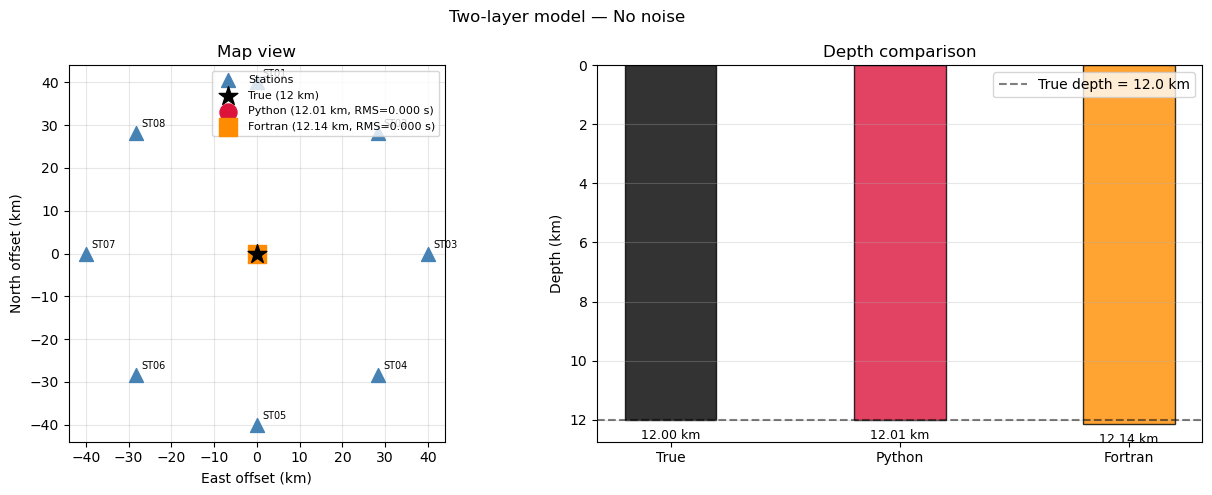

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sta_lons = [s.lon for s in stations]
sta_lats = [s.lat for s in stations]

# Convert degrees to km offsets from true epicentre
def to_km(lons, lats):
    dx = (np.asarray(lons) - TRUE_LON) / deg_per_km_lon
    dy = (np.asarray(lats) - TRUE_LAT) / deg_per_km_lat
    return dx, dy

# --- Left: map view (epicentre + stations) ---
ax = axes[0]
sx, sy = to_km(sta_lons, sta_lats)
ax.scatter(sx, sy, s=100, marker='^', color='steelblue', zorder=5, label='Stations')
for s, x, y in zip(stations, sx, sy):
    ax.annotate(s.code, (x, y), textcoords='offset points', xytext=(4, 4), fontsize=7)

ax.scatter(0, 0, s=200, marker='*', color='black', zorder=10,
           label=f'True ({TRUE_DEPTH:.0f} km)')
py_x, py_y = to_km(py_lon, py_lat)
ax.scatter(py_x, py_y, s=150, marker='o', color='crimson', zorder=9,
           label=f'Python ({py_depth:.2f} km, RMS={py_rms:.3f} s)')
ft_x, ft_y = to_km(ft_lon, ft_lat)
ax.scatter(ft_x, ft_y, s=150, marker='s', color='darkorange', zorder=9,
           label=f'Fortran ({ft_depth:.2f} km, RMS={ft_rms:.3f} s)')

ax.set_xlabel('East offset (km)')
ax.set_ylabel('North offset (km)')
ax.set_title('Map view')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# --- Right: depth comparison bar chart ---
ax2 = axes[1]
labels = ['True', 'Python', 'Fortran']
depths = [TRUE_DEPTH, float(py_depth), float(ft_depth)]
colors = ['black', 'crimson', 'darkorange']
bars = ax2.bar(labels, depths, color=colors, alpha=0.8, edgecolor='k', width=0.4)
ax2.axhline(TRUE_DEPTH, color='black', linestyle='--', alpha=0.5,
            label=f'True depth = {TRUE_DEPTH} km')
ax2.set_ylabel('Depth (km)')
ax2.set_title('Depth comparison')
ax2.invert_yaxis()
for bar, d in zip(bars, depths):
    ax2.text(bar.get_x() + bar.get_width()/2, d + 0.3, f'{d:.2f} km',
             ha='center', va='top', fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

noise_label = f'σP={SIGMA_P} s, σS={SIGMA_S} s' if (SIGMA_P or SIGMA_S) else 'No noise'
fig.suptitle(f'Two-layer model — {noise_label}', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Noise Sweep: Location Error vs Pick Uncertainty

Run both locators at multiple noise levels and compare how each degrades.
Each noise level is run `n_trials` times with different random seeds.

### Batch Fortran helper

Running a fresh subprocess for every noise-sweep trial would be slow (~50–100 calls).
HYPO71 is designed for batch use: after the header (TEST variables, station list,
velocity model, control card) you simply append phase sections one after another;
the binary reads them sequentially until EOF and writes one solution line per event
to `HYPO71.PUN`.

`run_fortran_batch` exploits this:
1. Calls `write_hypo71_input` to write the header **and first event** to `HYPO71.INP`.
2. Appends the remaining events using `_write_event_phases`, which reproduces the
   phase-card + instruction-card format that `write_hypo71_input` uses internally.
3. Launches the binary **once**; all events are processed in a single run.
4. Parses every solution from `HYPO71.PUN` and returns them in input order.

As with the single-event helper, everything lives in a `tempfile.TemporaryDirectory`
and is cleaned up automatically — no files are left on disk after the call returns.


In [9]:
def _write_event_phases(picks_dict, stations, use_s):
    """
    Return a string of phase cards + instruction card for one event.
    Mirrors the phase-writing logic in write_hypo71_input so that additional
    events can be appended to an existing batch HYPO71.INP file.
    """
    def _to_utc(pick):
        if pick is None: return None
        return pick.datetime if hasattr(pick, 'datetime') else pick

    lines = []
    ref_p = next((_to_utc(v.get('P')) for v in picks_dict.values()
                  if _to_utc(v.get('P')) is not None), None)
    if ref_p is None:
        raise ValueError('No P picks found in event')

    year2    = ref_p.year % 100
    yymmdd   = f'{year2:02d}{ref_p.month:02d}{ref_p.day:02d}'
    ref_hour = ref_p.hour

    for sta in stations:
        # Try full code first, then bare station name (sta.sta)
        phase  = picks_dict.get(sta.code) or picks_dict.get(sta.sta, {})
        p_time = _to_utc(phase.get('P'))
        s_time = _to_utc(phase.get('S'))
        if p_time is None:
            continue

        p_min = p_time.minute
        p_sec = p_time.second + p_time.microsecond * 1e-6
        card  = [' '] * 80
        card[0:4]  = list(f'{code:<4s}'[:4])
        card[4]    = 'I'; card[5] = 'P'; card[7] = '0'
        card[9:15] = list(yymmdd)
        card[15:17] = list(f'{ref_hour:02d}')
        card[17:19] = list(f'{p_min:02d}')
        card[19:24] = list(f'{p_sec:5.2f}')

        if s_time is not None and use_s:
            p_min_base  = UTCDateTime(p_time.year, p_time.month, p_time.day,
                                      p_time.hour, p_time.minute, 0)
            s_sec_card  = float(s_time - p_min_base)
            card[31:36] = list(f'{s_sec_card:5.2f}')
            card[36]    = 'E'; card[37] = 'S'; card[39] = '0'

        lines.append(''.join(card))

    # Instruction / termination card — blank MSTA triggers SINGLE for this event
    inst_card       = [' '] * 80
    inst_card[17]   = '1' if use_s else '0'   # KNST digit
    inst_card[18]   = '0'                       # INST digit
    lines.append(''.join(inst_card))
    return '\n'.join(lines) + '\n'


def run_fortran_batch(stations, events_list, vel, ztr=5.0, use_s=True):
    """
    Locate multiple events in a single Fortran subprocess call.

    HYPO71 is designed for batch processing: the station list, velocity model,
    and control card are written once; then all event phase sections are
    appended sequentially.  The binary processes them in order, writing one
    solution line per event to HYPO71.PUN.

    Parameters
    ----------
    events_list : list of pick_dicts
        Each element is a {station_code: {'P': PhasePick, 'S': PhasePick}} dict.

    Returns
    -------
    solutions : list of dicts
        One entry per event that produced a solution (same order as input).
        Events that fail to locate are silently dropped by the Fortran binary —
        check len(solutions) == len(events_list) if ordering matters.
    """
    if not events_list:
        return []

    with tempfile.TemporaryDirectory() as tmp:
        inp = Path(tmp) / 'HYPO71.INP'

        # Header (TEST vars, stations, velocity model, control card) + first event
        write_hypo71_input(inp, stations, events_list[0], vel, ztr=ztr, use_s=use_s)

        # Append remaining events — the Fortran reads them sequentially until EOF
        if len(events_list) > 1:
            with open(inp, 'a') as fh:
                for pd in events_list[1:]:
                    fh.write(_write_event_phases(pd, stations, use_s))

        proc = subprocess.run(
            [str(FORTRAN_BIN)],
            input=b'\n\n\n\n\n\n',
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            cwd=tmp,
        )
        assert proc.returncode == 0, (
            f'Fortran exited {proc.returncode}\n'
            f'stderr: {proc.stderr.decode()[:300]}'
        )
        return parse_hypo71_pun(Path(tmp) / 'HYPO71.PUN')

In [10]:
sigma_values = [0.0, 0.02, 0.05, 0.10, 0.20]   # s — P-pick standard deviation
n_trials     = 10                               # realisations per noise level

# ------------------------------------------------------------------
# 1. Generate all events upfront so Python and Fortran see identical picks
# ------------------------------------------------------------------
all_events = []   # list of (sigma_p, trial, pick_dict)
for sig_p in sigma_values:
    sig_s = sig_p * 2.0
    for trial in range(n_trials):
        seed = trial + int(sig_p * 1000)
        noisy_picks, _ = add_noise_to_picks(picks_true,
                                            sigma_p_s=sig_p, sigma_s_s=sig_s,
                                            seed=seed)
        picks = {code: {'P': ph['P'], 'S': ph['S']} for code, ph in noisy_picks.items()}
        all_events.append((sig_p, trial, picks))

# ------------------------------------------------------------------
# 2. Python — one SINGLE call per event (fast, stateless)
# ------------------------------------------------------------------
sweep_results = []
for sig_p, trial, picks in all_events:
    try:
        r = SINGLE(stations, picks, vel, ZTR=ZTR, use_s_picks=True,
                   azimuthal_weighting=True, verbose=0)
        sweep_results.append({'sigma_p': sig_p, 'trial': trial, 'locator': 'Python',
                               'lon': float(r[0]), 'lat': float(r[1]),
                               'depth': float(r[2]), 'rms': float(r[8])})
    except Exception as e:
        print(f'Python failed (σ={sig_p}, trial={trial}): {e}')

# ------------------------------------------------------------------
# 3. Fortran — all events in a single subprocess call
#    run_fortran_batch writes one HYPO71.INP with all events appended
#    sequentially; the binary processes them in order until EOF.
# ------------------------------------------------------------------
ft_pds      = [picks for _, _, picks in all_events]
ft_metadata = [(sig_p, trial) for sig_p, trial, _ in all_events]

ft_solutions = run_fortran_batch(stations, ft_pds, vel, ztr=ZTR, use_s=True)

if len(ft_solutions) != len(ft_pds):
    print(f'Warning: expected {len(ft_pds)} Fortran solutions, got {len(ft_solutions)}. '
          'Some events may have failed to locate.')

for (sig_p, trial), sol in zip(ft_metadata, ft_solutions):
    sweep_results.append({'sigma_p': sig_p, 'trial': trial, 'locator': 'Fortran',
                          'lon': sol['lon'], 'lat': sol['lat'],
                          'depth': sol['depth'], 'rms': sol['rms']})

n_py = sum(1 for r in sweep_results if r['locator'] == 'Python')
n_ft = sum(1 for r in sweep_results if r['locator'] == 'Fortran')
print(f'Collected {len(sweep_results)} results: {n_py} Python + {n_ft} Fortran  '
      f'({len(sigma_values)} noise levels × {n_trials} trials, 1 Fortran subprocess)')

Collected 100 results: 50 Python + 50 Fortran  (5 noise levels × 10 trials, 1 Fortran subprocess)


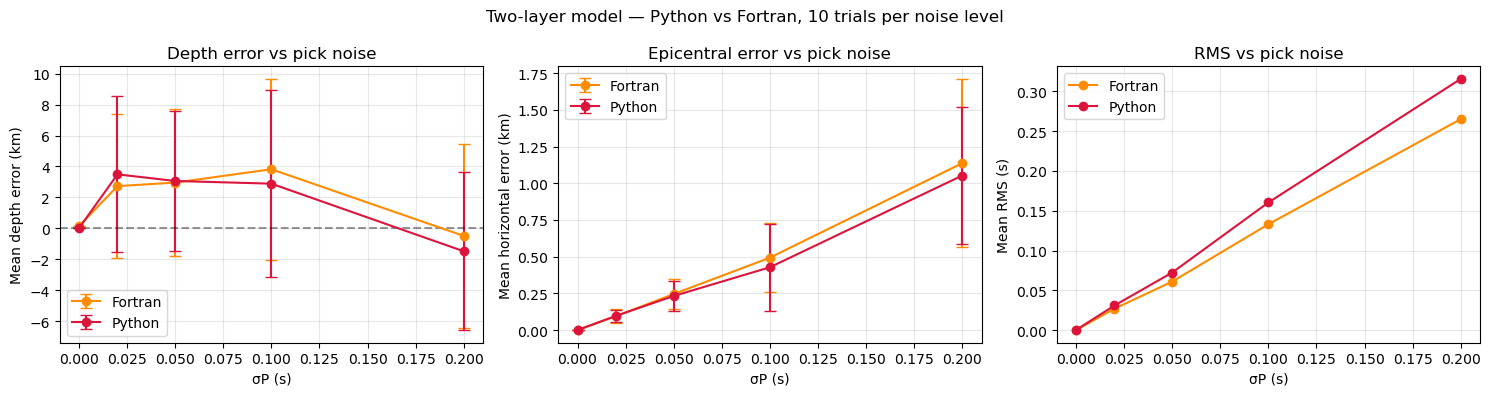

In [11]:
df = pd.DataFrame(sweep_results)
df['depth_err'] = df['depth'] - TRUE_DEPTH
df['horiz_err'] = df.apply(
    lambda r: epicentral_error_km(r['lon'] - TRUE_LON, r['lat'] - TRUE_LAT), axis=1)

summary = df.groupby(['sigma_p', 'locator']).agg(
    mean_depth_err=('depth_err', 'mean'),
    std_depth_err=('depth_err', 'std'),
    mean_horiz_err=('horiz_err', 'mean'),
    std_horiz_err=('horiz_err', 'std'),
    mean_rms=('rms', 'mean'),
).reset_index()

palette = {'Python': 'crimson', 'Fortran': 'darkorange'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for locator, grp in summary.groupby('locator'):
    color = palette[locator]
    x = grp['sigma_p']
    axes[0].errorbar(x, grp['mean_depth_err'], yerr=grp['std_depth_err'],
                     marker='o', label=locator, color=color, capsize=4)
    axes[1].errorbar(x, grp['mean_horiz_err'], yerr=grp['std_horiz_err'],
                     marker='o', label=locator, color=color, capsize=4)
    axes[2].plot(x, grp['mean_rms'], marker='o', label=locator, color=color)

axes[0].axhline(0, color='k', linestyle='--', alpha=0.4)
axes[0].set_xlabel('σP (s)'); axes[0].set_ylabel('Mean depth error (km)')
axes[0].set_title('Depth error vs pick noise'); axes[0].legend()

axes[1].set_xlabel('σP (s)'); axes[1].set_ylabel('Mean horizontal error (km)')
axes[1].set_title('Epicentral error vs pick noise'); axes[1].legend()

axes[2].set_xlabel('σP (s)'); axes[2].set_ylabel('Mean RMS (s)')
axes[2].set_title('RMS vs pick noise'); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Two-layer model — Python vs Fortran, {n_trials} trials per noise level',
             fontsize=12)
plt.tight_layout()
plt.show()

## 8. Real Data — Apollo Bay Aftershocks

This section relocates the 92 aftershocks of the 2023 $M_L$ 5.0 Apollo Bay,
Victoria event using both the Python `SINGLE` and the Fortran binary, then
compares the solutions side-by-side.

**Data files** (relative to `notebooks/data/`):
- `seisbench_cat.xml` — ObsPy QuakeML catalog (picks + automatic origins from SeisComP/SeisML)
- `apollo_bay_metadata/*.xml` — StationXML files for the 9-station local array
- `ensemble_avg.csv` — regional 1-D Vp/Vs model averaged from an ensemble inversion

**Settings used by both locators**:
- Trial depth `ZTR = 5.0 km` (fixed; original Fortran design uses one value per run)
- S picks included (`use_s=True` / `KNST=1`)
- Azimuthal weighting enabled (Python only; Fortran control-card default)
- Events with fewer than 3 picked stations are skipped


In [12]:
from hypo71py.interface.obspy import load_stations_from_stationxml, match_stations_to_picks
from hypo71py.model.station_phase import build_pick_dict_from_event
from hypo71py.model.velocity_model import load_velocity_model_from_csv
from obspy import read_events as _read_events

DATA_DIR = REPO_ROOT / 'notebooks' / 'data'

# Load stations — keep full NET.STA codes; matching is handled by station.sta
real_stations = load_stations_from_stationxml(DATA_DIR / 'apollo_bay_metadata')
print(f'Stations ({len(real_stations)}): {[s.sta for s in real_stations]}')

# Load the QuakeML catalog
real_cat = _read_events(str(DATA_DIR / 'seisbench_cat.xml'))
print(f'Events: {len(real_cat)}')

# Regional 1-D velocity model
real_vel = load_velocity_model_from_csv(str(DATA_DIR / 'ensemble_avg.csv'),
                                        name='apollo_bay')
print(real_vel)

REAL_ZTR = 5.0   # km — trial depth for both Python and Fortran


Stations (8): ['ABM1Y', 'ABM2Y', 'ABM3Y', 'ABM4Y', 'ABM5Y', 'ABM6Y', 'ABM7Y', 'FRTM']
Events: 92
✅ Loaded velocity model 'apollo_bay' from /Users/DSAND/projects/earthquake_research_group/hypo71py/notebooks/data/ensemble_avg.csv
<CrustalVelocityModel "apollo_bay" (n=5)>


### Python relocation

`SINGLE` is called once per event.  The Fortran f2py travel-time extension
(`use_fortran_speedups=True`, the default) is used — the TRVDRV state-corruption
bug that affected multi-model runs was fixed in a prior session, so this is safe.


In [13]:
real_py_results = []

for ev in real_cat:
    origin_info, pick_dict, picked_codes = build_pick_dict_from_event(ev)
    subs, _ = match_stations_to_picks(real_stations, picked_codes)
    if len(subs) < 3:
        continue
    try:
        r = SINGLE(subs, pick_dict, real_vel,
                   ZTR=REAL_ZTR, use_s_picks=True,
                   azimuthal_weighting=True, verbose=0)
        real_py_results.append({
            'event_id':   ev.resource_id.id,
            'locator':    'Python',
            'orig_lat':   origin_info['latitude'],
            'orig_lon':   origin_info['longitude'],
            'orig_depth': origin_info['depth_km'],
            'lon':   float(r[0]),
            'lat':   float(r[1]),
            'depth': float(r[2]),
            'rms':   float(r[8]),
        })
    except Exception as e:
        print(f'Python failed ({ev.resource_id.id}): {e}')

print(f'Python: {len(real_py_results)} / {len(real_cat)} events located')


Python: 92 / 92 events located


### Fortran relocation (batch)

All events are written to a **single `HYPO71.INP`** and processed in one subprocess
call (same `run_fortran_batch` helper used in the noise sweep above).

The full station list is written in the file header once.  Each event's phase
section then only includes cards for stations that have a pick — stations without
picks in a given event are simply skipped by `_write_event_phases`.

Because `ZTR` is a single control-card value that applies to the whole batch,
the same fixed trial depth (5.0 km) is used here as in the Python run.


In [14]:
# Build pick_dicts for all locatable events (same ≥3-station filter as Python)
real_ft_events = []   # list of (event_id, origin_info, pick_dict)
for ev in real_cat:
    origin_info, pick_dict, picked_codes = build_pick_dict_from_event(ev)
    subs, _ = match_stations_to_picks(real_stations, picked_codes)
    if len(subs) >= 3:
        real_ft_events.append((ev.resource_id.id, origin_info, pick_dict))

ft_pds  = [picks for _, _,  picks in real_ft_events]
ft_meta = [(eid, oi) for eid, oi, _ in real_ft_events]

# Single subprocess — all events in one HYPO71.INP
ft_solutions = run_fortran_batch(real_stations, ft_pds, real_vel,
                                 ztr=REAL_ZTR, use_s=True)

if len(ft_solutions) != len(ft_pds):
    print(f'Warning: expected {len(ft_pds)} solutions, got {len(ft_solutions)}. '
          'Some events may not have converged.')

real_ft_results = []
for (eid, oi), sol in zip(ft_meta, ft_solutions):
    real_ft_results.append({
        'event_id':   eid,
        'locator':    'Fortran',
        'orig_lat':   oi['latitude'],
        'orig_lon':   oi['longitude'],
        'orig_depth': oi['depth_km'],
        'lon':   sol['lon'],
        'lat':   sol['lat'],
        'depth': sol['depth'],
        'rms':   sol['rms'],
    })

print(f'Fortran: {len(real_ft_results)} / {len(real_cat)} events located '
      f'(1 subprocess, {len(ft_pds)} events batched)')


Fortran: 92 / 92 events located (1 subprocess, 92 events batched)


### Comparison


In [15]:
real_df = pd.DataFrame(real_py_results + real_ft_results)

# Paired table — one row per event, columns for Python and Fortran
py_df = real_df[real_df.locator == 'Python'].set_index('event_id')
ft_df = real_df[real_df.locator == 'Fortran'].set_index('event_id')
merged = py_df.join(ft_df, lsuffix='_py', rsuffix='_ft', how='inner')
merged['Δlon_deg']   = merged.lon_py   - merged.lon_ft
merged['Δlat_deg']   = merged.lat_py   - merged.lat_ft
merged['Δdepth_km']  = merged.depth_py - merged.depth_ft
merged['Δrms_s']     = merged.rms_py   - merged.rms_ft

km_per_deg = 111.2
merged['Δhoriz_km'] = np.sqrt(
    (merged.Δlon_deg * km_per_deg * np.cos(np.radians(merged.lat_py))) ** 2
    + (merged.Δlat_deg * km_per_deg) ** 2
)

print(f'{len(merged)} events in common (Python ∩ Fortran)\n')
print(merged[['Δlon_deg', 'Δlat_deg', 'Δdepth_km', 'Δhoriz_km', 'Δrms_s']]
      .describe().round(4))


92 events in common (Python ∩ Fortran)

       Δlon_deg  Δlat_deg  Δdepth_km  Δhoriz_km   Δrms_s
count   92.0000   92.0000    92.0000    92.0000  92.0000
mean    -0.0005    0.0007    -0.1334     0.1988   0.0472
std      0.0022    0.0023     0.4652     0.2673   0.0530
min     -0.0093   -0.0019    -2.0600     0.0051  -0.0007
25%     -0.0008   -0.0004    -0.2962     0.0445   0.0112
50%     -0.0002    0.0000    -0.0392     0.1106   0.0226
75%      0.0004    0.0008     0.0766     0.2136   0.0694
max      0.0071    0.0107     0.9373     1.4324   0.2508


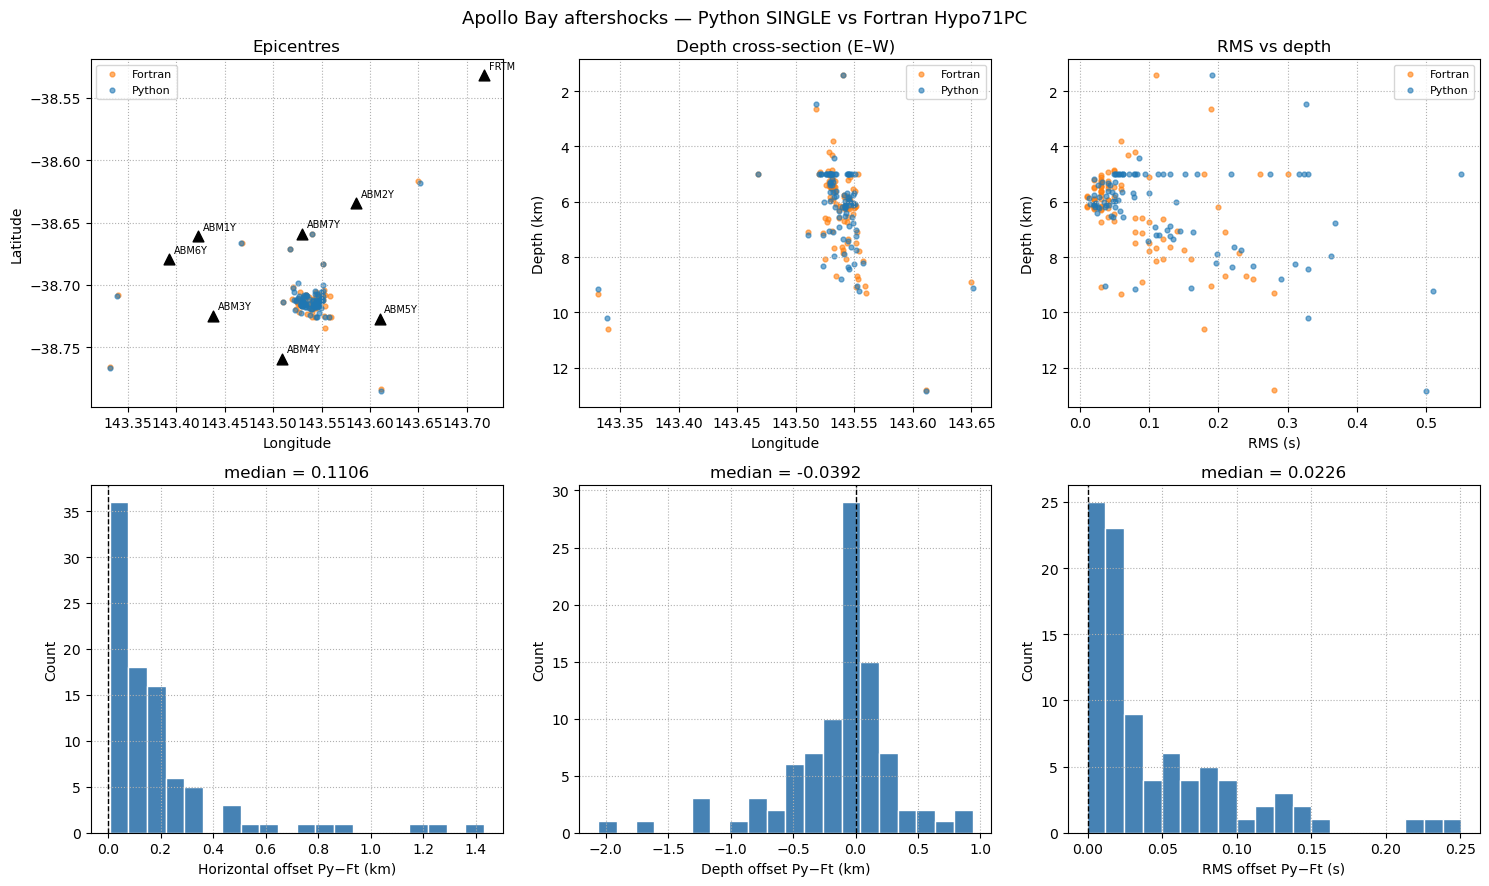

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

colors = {'Python': 'tab:blue', 'Fortran': 'tab:orange'}

# --- Row 1: map and depth cross-sections ---
ax = axes[0, 0]
for loc, grp in real_df.groupby('locator'):
    ax.scatter(grp.lon, grp.lat, s=12, alpha=0.6,
               label=loc, color=colors[loc])
st_lons = [s.lon for s in real_stations]
st_lats = [s.lat for s in real_stations]
ax.scatter(st_lons, st_lats, marker='^', s=60, color='k', zorder=5)
for s in real_stations:
    ax.text(s.lon + 0.005, s.lat + 0.005, s.sta,  fontsize=7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Epicentres'); ax.legend(fontsize=8); ax.grid(ls=':')

ax = axes[0, 1]
for loc, grp in real_df.groupby('locator'):
    ax.scatter(grp.lon, grp.depth, s=12, alpha=0.6,
               label=loc, color=colors[loc])
ax.invert_yaxis()
ax.set_xlabel('Longitude'); ax.set_ylabel('Depth (km)')
ax.set_title('Depth cross-section (E–W)'); ax.legend(fontsize=8); ax.grid(ls=':')

ax = axes[0, 2]
for loc, grp in real_df.groupby('locator'):
    ax.scatter(grp.rms, grp.depth, s=12, alpha=0.6,
               label=loc, color=colors[loc])
ax.invert_yaxis()
ax.set_xlabel('RMS (s)'); ax.set_ylabel('Depth (km)')
ax.set_title('RMS vs depth'); ax.legend(fontsize=8); ax.grid(ls=':')

# --- Row 2: Python vs Fortran difference histograms ---
for col, xlabel, ax in [
    ('Δhoriz_km',  'Horizontal offset Py−Ft (km)',  axes[1, 0]),
    ('Δdepth_km',  'Depth offset Py−Ft (km)',        axes[1, 1]),
    ('Δrms_s',     'RMS offset Py−Ft (s)',           axes[1, 2]),
]:
    ax.hist(merged[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel(xlabel); ax.set_ylabel('Count')
    med = merged[col].median()
    ax.set_title(f'median = {med:.4f}'); ax.grid(ls=':')

fig.suptitle('Apollo Bay aftershocks — Python SINGLE vs Fortran Hypo71PC', fontsize=13)
plt.tight_layout()
plt.show()
